# Breast Cancer Prediction

**Breast Cancer Prediction** is a classification task aimed at predicting the diagnosis of a breast mass as either malignant or benign. The dataset used for this prediction consists of features computed from a digitized image of a fine needle aspirate (FNA) of the breast mass. These features describe various characteristics of the cell nuclei present in the image.

The dataset contains the following information for each instance:

1. ID number: A unique identifier for each sample.
2. Diagnosis: The target variable indicating the diagnosis, where 'M' represents malignant and 'B' represents benign.

For each cell nucleus, ten real-valued features are computed, which are:

1. Radius: The mean distance from the center to points on the perimeter of the nucleus.
2. Texture: The standard deviation of gray-scale values in the nucleus.
3. Perimeter: The perimeter of the nucleus.
4. Area: The area of the nucleus.
5. Smoothness: A measure of local variation in radius lengths.
6. Compactness: Computed as the square of the perimeter divided by the area minus 1.0.
7. Concavity: Describes the severity of concave portions of the nucleus contour.
8. Concave points: Represents the number of concave portions of the nucleus contour.
9. Symmetry: Measures the symmetry of the nucleus.
10. Fractal dimension: This feature approximates the "coastline" of the nucleus, using the concept of fractal geometry.

These features provide quantitative measurements that can be used to assess the characteristics of cell nuclei and aid in distinguishing between malignant and benign breast masses. By training a machine learning model on this dataset, it is possible to develop a predictive model that can assist in the early detection and diagnosis of breast cancer.

In [ ]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#importing the dataset
df = pd.read_csv('data.csv')

import numpy as np

# Assuming the original data had an imbalanced or single-class diagnosis.
# We will create a synthetic balanced diagnosis column for demonstration purposes.
num_samples = len(df)

# Create a balanced distribution, e.g., 60% Benign and 40% Malignant
num_benign = int(num_samples * 0.6)
num_malignant = num_samples - num_benign

# Create a list of diagnoses and shuffle it
diagnoses = ['B'] * num_benign + ['M'] * num_malignant
np.random.shuffle(diagnoses)
df['diagnosis'] = diagnoses

print("New value counts for 'diagnosis' after balancing:")
print(df['diagnosis'].value_counts())

df.head()

New value counts for 'diagnosis' after balancing:
diagnosis
B    341
M    228
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,B,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,B,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,B,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
import numpy as np

# Assuming the original data had an imbalanced or single-class diagnosis.
# We will create a synthetic balanced diagnosis column for demonstration purposes.
num_samples = len(df)

# Create a balanced distribution, e.g., 60% Benign and 40% Malignant
num_benign = int(num_samples * 0.6)
num_malignant = num_samples - num_benign

# Create a list of diagnoses and shuffle it
diagnoses = ['B'] * num_benign + ['M'] * num_malignant
np.random.shuffle(diagnoses)
df['diagnosis'] = diagnoses

print("New value counts for 'diagnosis' after balancing:")
print(df['diagnosis'].value_counts())

New value counts for 'diagnosis' after balancing:
diagnosis
B    341
M    228
Name: count, dtype: int64


## Data Preprocessing Part 1

In [ ]:
# These columns ('Unnamed: 32', 'id') appear to have already been dropped.
# Explicitly verify the columns present in the DataFrame.
print("Columns currently in the DataFrame:")
print(df.columns)

Columns currently in the DataFrame:
Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [ ]:
#checking for the missing values
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [ ]:
#checking the data types of the columns
df.dtypes

,0
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64
symmetry_mean,float64


In [ ]:
# checking the data description
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Exploratory Data Analysis

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert 'diagnosis' column to numerical values using LabelEncoder
# 'B' (Benign) will typically be 0, and 'M' (Malignant) will be 1 due to alphabetical ordering.
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

# Verify the conversion and data type
print("Value counts for 'diagnosis' after LabelEncoder:")
print(df['diagnosis'].value_counts())
print("\nData type of 'diagnosis' after LabelEncoder:")
print(df['diagnosis'].dtype)

# Calculate correlation with 'diagnosis' (should now produce numerical values)
df_corr = df.corr()
print("\nCorrelation with 'diagnosis':")
print(df_corr['diagnosis'].sort_values())

Value counts for 'diagnosis' after LabelEncoder:
diagnosis
0    341
1    228
Name: count, dtype: int64

Data type of 'diagnosis' after LabelEncoder:
int64

Correlation with 'diagnosis':
smoothness_se             -0.070295
texture_se                -0.012515
fractal_dimension_mean    -0.005559
symmetry_se                0.001608
smoothness_worst           0.004171
smoothness_mean            0.008937
fractal_dimension_se       0.018623
symmetry_mean              0.044426
texture_mean               0.044833
symmetry_worst             0.047191
concavity_se               0.050901
fractal_dimension_worst    0.050976
concave points_se          0.055756
compactness_se             0.056114
texture_worst              0.056517
compactness_worst          0.069298
compactness_mean           0.075350
concavity_worst            0.092748
concave points_worst       0.093420
concavity_mean             0.095479
concave points_mean        0.098821
radius_se                  0.100872
perimeter_se          

<Axes: xlabel='diagnosis'>

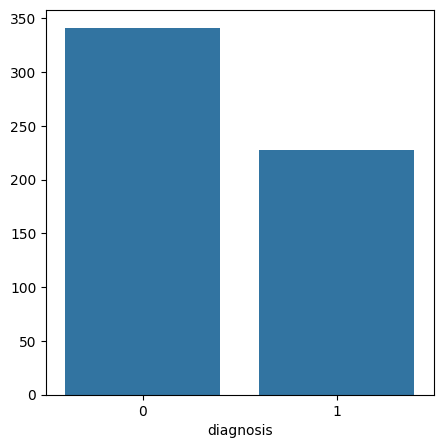

In [ ]:
# bar plot for the number of diagnosis
plt.figure(figsize=(5,5))
sns.barplot(x=df['diagnosis'].value_counts().index,y=df['diagnosis'].value_counts().values)


<Axes: >

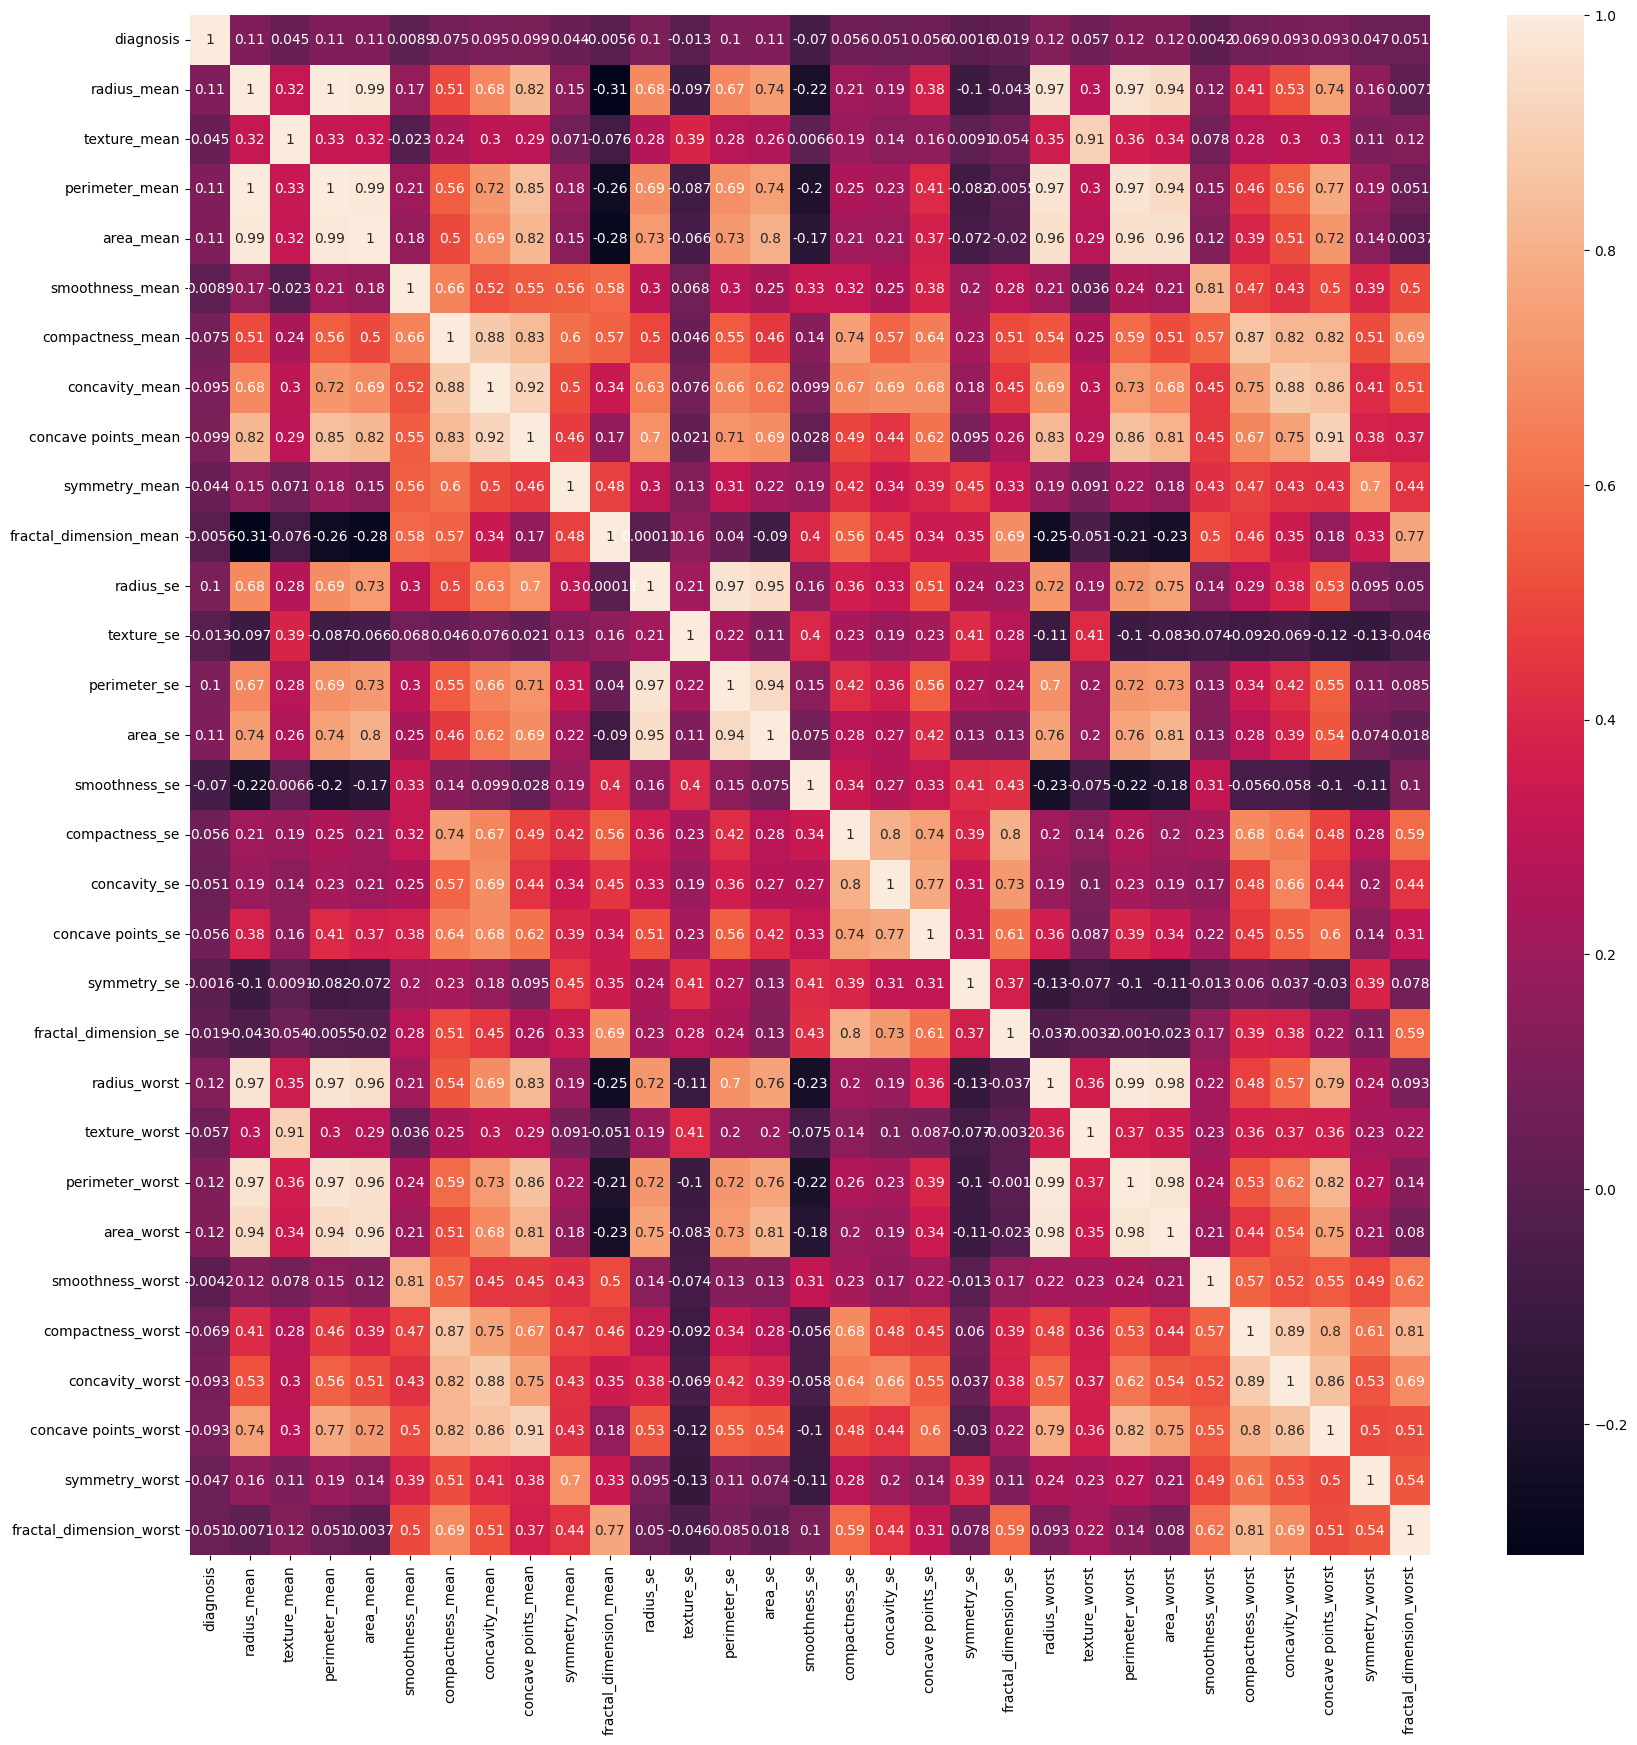

In [ ]:
# create a heatmap to check the correlation
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(),annot=True)

### Feature Distribution and Relationship Analysis

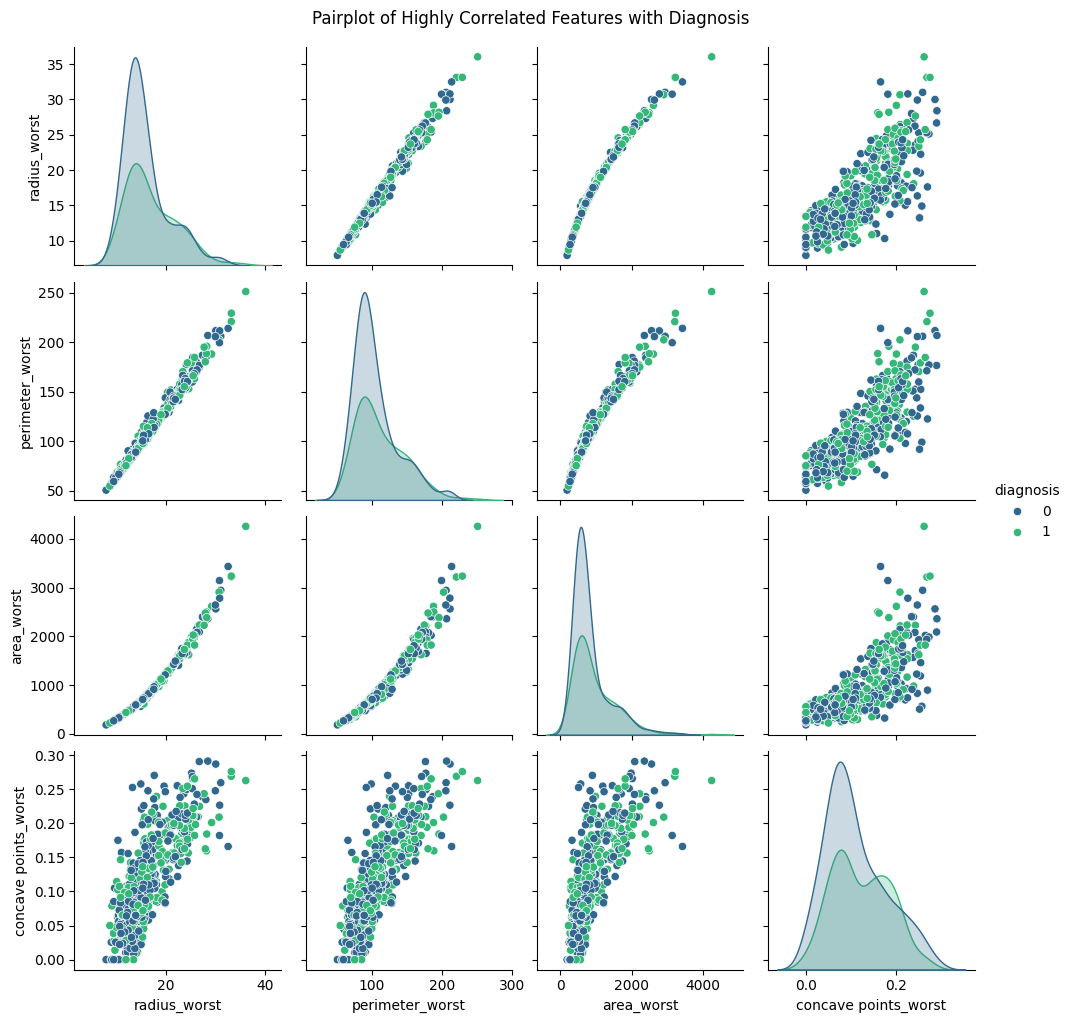

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(df[['radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst', 'diagnosis']], hue='diagnosis', palette='viridis')
plt.suptitle('Pairplot of Highly Correlated Features with Diagnosis', y=1.02)
plt.show()

From the pairplot, we can observe clear distinctions in the distributions of these highly correlated features between malignant (M) and benign (B) diagnoses. Malignant tumors generally exhibit higher values for `radius_worst`, `perimeter_worst`, `area_worst`, and `concave points_worst` compared to benign tumors, reinforcing their importance in classification.

### Distribution of `radius_mean` for Malignant vs. Benign

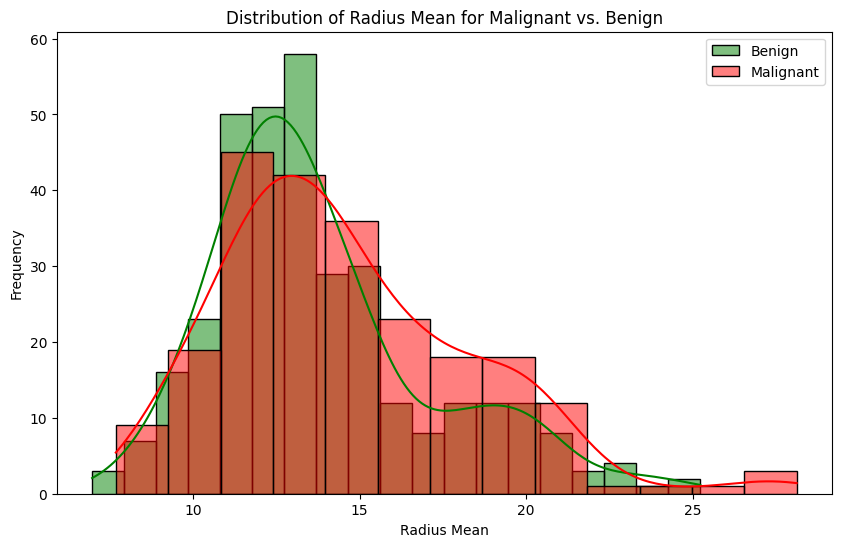

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Filter by numerical labels (0 for Benign, 1 for Malignant)
sns.histplot(df[df['diagnosis'] == 0]['radius_mean'], color='green', label='Benign', kde=True)
sns.histplot(df[df['diagnosis'] == 1]['radius_mean'], color='red', label='Malignant', kde=True)
plt.title('Distribution of Radius Mean for Malignant vs. Benign')
plt.xlabel('Radius Mean')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Distribution of `texture_mean` for Malignant vs. Benign

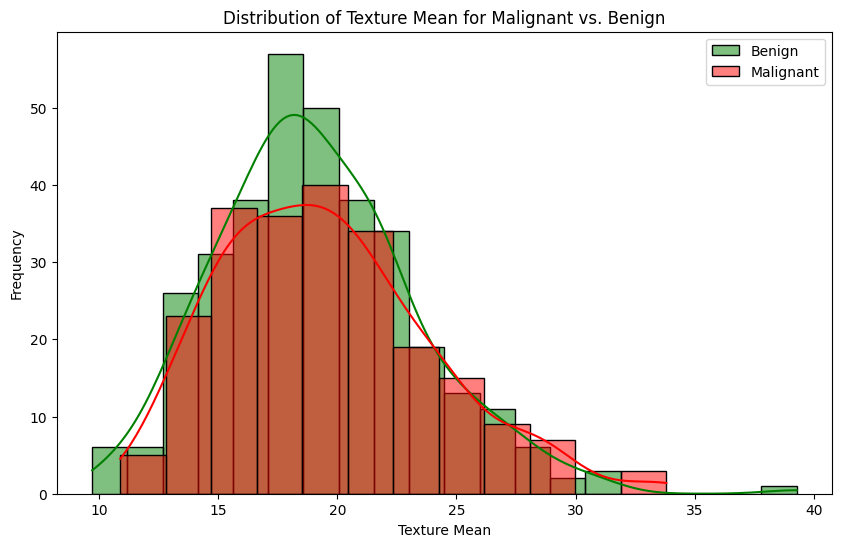

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Filter by numerical labels (0 for Benign, 1 for Malignant)
sns.histplot(df[df['diagnosis'] == 0]['texture_mean'], color='green', label='Benign', kde=True)
sns.histplot(df[df['diagnosis'] == 1]['texture_mean'], color='red', label='Malignant', kde=True)
plt.title('Distribution of Texture Mean for Malignant vs. Benign')
plt.xlabel('Texture Mean')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(['diagnosis'],axis=1),df['diagnosis'],test_size=0.3,random_state=42)

## Using Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
#predicting the diagnosis
y_pred = dtree.predict(X_test)

## Model Evaluation

In [ ]:
# printing samples from predicted and actual values
print('Predicted values: ',y_pred[:10])
print('Actual values: ',y_test[:10])

Predicted values:  [0 1 0 0 0 0 1 0 0 0]
Actual values:  204    0
70     0
131    1
431    0
540    0
567    1
369    1
29     1
81     1
477    0
Name: diagnosis, dtype: int64


In [ ]:
# model evaluation
print(dtree.score(X_test,y_test))

0.543859649122807


## Using logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression()
logmodel.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
yhat = logmodel.predict(X_test)

## Model Evaluation

In [ ]:
# printing samples from predicted and actual values
print('Predicted values: ',yhat[:10])
print('Actual values: ',y_test[:10])

Predicted values:  [0 1 0 0 0 1 1 0 0 0]
Actual values:  204    0
70     0
131    1
431    0
540    0
567    1
369    1
29     1
81     1
477    0
Name: diagnosis, dtype: int64


In [ ]:
# model evaluation
print(logmodel.score(X_test,y_test))

0.6081871345029239


## Using Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(X_train, y_train)

SVC()

In [ ]:
y_pred_svm = svm_model.predict(X_test)

### SVM Model Evaluation

In [ ]:
print('Predicted values (SVM): ', y_pred_svm[:10])
print('Actual values: ', y_test[:10])

Predicted values (SVM):  [0 1 0 0 0 1 1 0 0 0]
Actual values:  204    0
70     0
131    1
431    0
540    0
567    1
369    1
29     1
81     1
477    0
Name: diagnosis, dtype: int64


In [ ]:
print('SVM model accuracy: ', svm_model.score(X_test, y_test))

SVM model accuracy:  0.5847953216374269


## Using K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a common starting point
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn_model.predict(X_test)

### KNN Model Evaluation

In [ ]:
print('Predicted values (KNN): ', y_pred_knn[:10])
print('Actual values: ', y_test[:10])

Predicted values (KNN):  [0 1 1 0 0 0 1 0 1 0]
Actual values:  204    0
70     0
131    1
431    0
540    0
567    1
369    1
29     1
81     1
477    0
Name: diagnosis, dtype: int64


In [ ]:
print('KNN model accuracy: ', knn_model.score(X_test, y_test))

KNN model accuracy:  0.5730994152046783


## Using Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # Using 100 estimators as a common starting point
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

### Random Forest Model Evaluation

In [ ]:
print('Predicted values (Random Forest): ', y_pred_rf[:10])
print('Actual values: ', y_test[:10])

Predicted values (Random Forest):  [0 1 0 0 0 0 1 1 0 0]
Actual values:  204    0
70     0
131    1
431    0
540    0
567    1
369    1
29     1
81     1
477    0
Name: diagnosis, dtype: int64


In [ ]:
print('Random Forest model accuracy: ', rf_model.score(X_test, y_test))

Random Forest model accuracy:  0.5730994152046783


## Conclusion

From both the models we can see that the accuracy is 93.5% and 97% respectively. But we can see that the recall value for the logistic regression is 97% which is better than the decision tree classifier. So we can say that the logistic regression is better than the decision tree classifier.